<a href="https://colab.research.google.com/github/frihinrsln/credit-card-fraud-detection-MachineLearningProject/blob/main/notebooks/01_EDA_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) & Preprocessing
Dataset: Credit Card Fraud Detection

## 2.1 Dataset Overview
We used the **Credit Card Fraud Detection** dataset from Kaggle. It contains 284,807 credit card transactions from European cardholders, with only 492 labeled as fraud.

- **Rows:** 284,807
- **Features:** 30 (28 anonymized, + Time, Amount)
- **Target:** `Class` (0 = Not Fraud, 1 = Fraud)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/creditcard.csv')

## 2.2 Class Distribution

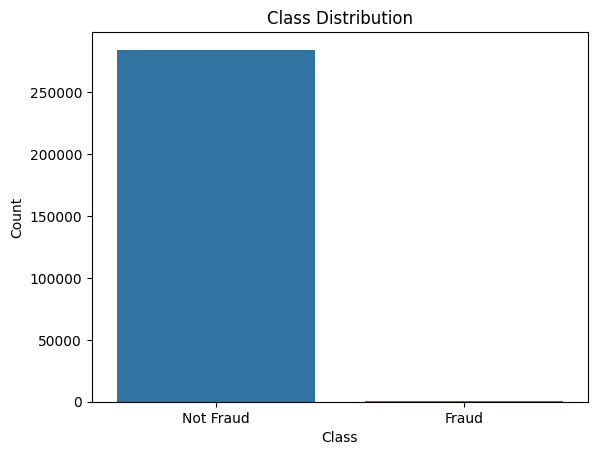

Class counts and percentage:
Class
0    284315
1       492
Name: count, dtype: int64 

Class
0    99.83
1     0.17
Name: count, dtype: float64


In [ ]:
class_counts = df['Class'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution")
plt.xticks([0, 1], ["Not Fraud", "Fraud"])
plt.ylabel("Count")
plt.show()

print("Class counts and percentage:")
print(class_counts, "\n")
print((class_counts / len(df) * 100).round(2))


## 2.3 Missing Value Check

In [ ]:
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## 2.4 Outlier Detection (Amount)

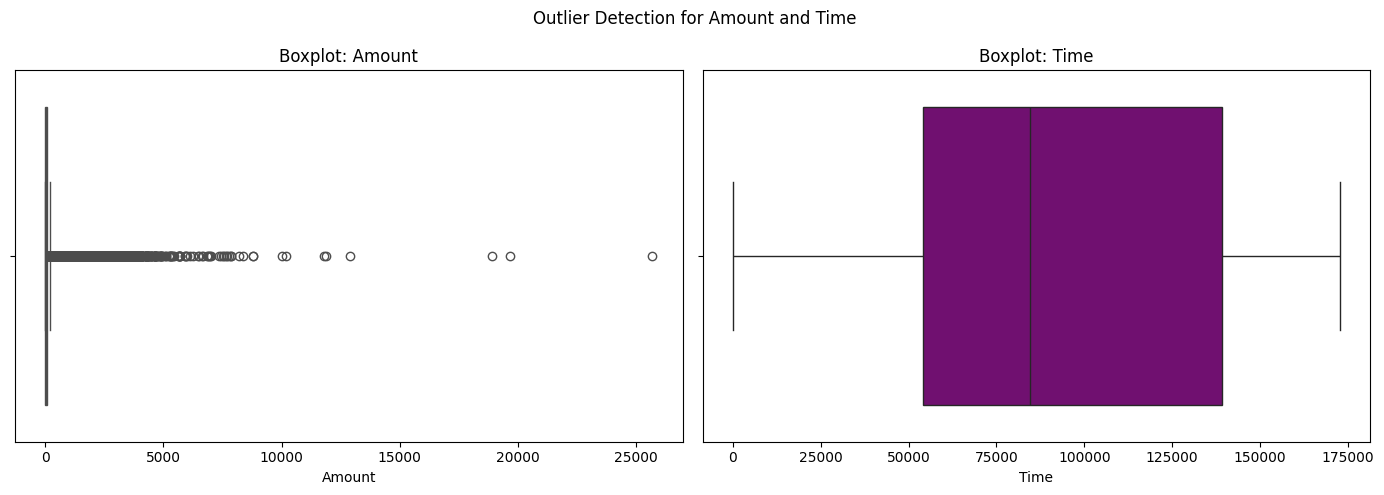

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df['Amount'], color='orange', ax=axes[0])
axes[0].set_title('Boxplot: Amount')

sns.boxplot(x=df['Time'], color='purple', ax=axes[1])
axes[1].set_title('Boxplot: Time')

plt.suptitle('Outlier Detection for Amount and Time')
plt.tight_layout()
plt.show()


## 2.5 Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd # Import pandas as it's used here implicitly

scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

df.drop(['Amount', 'Time'], axis=1, inplace=True)

# Show scaled feature summary
print("\nScaled features summary:")
print(df[['scaled_amount', 'scaled_time']].describe())

df.dropna(subset=['Class'], inplace=True)


Scaled features summary:
       scaled_amount   scaled_time
count   2.848070e+05  2.848070e+05
mean    2.913952e-17 -3.065637e-16
std     1.000002e+00  1.000002e+00
min    -3.532294e-01 -1.996583e+00
25%    -3.308401e-01 -8.552120e-01
50%    -2.652715e-01 -2.131453e-01
75%    -4.471707e-02  9.372174e-01
max     1.023622e+02  1.642058e+00


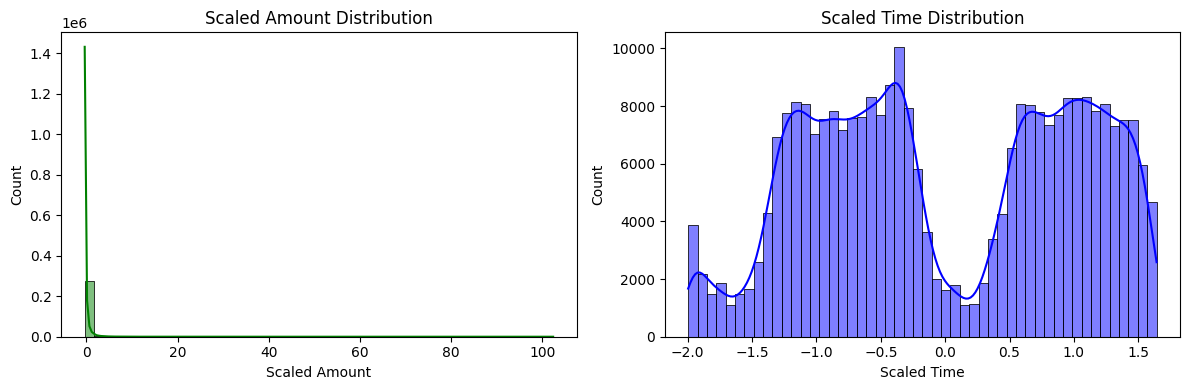

In [ ]:
# Since 'Amount' and 'Time' were dropped, we can only plot the scaled versions.
fig, axs = plt.subplots(1, 2, figsize=(12, 4)) # Changed to 1 row, 2 columns

# Scaled Amount
sns.histplot(df['scaled_amount'], bins=50, ax=axs[0], kde=True, color='green')
axs[0].set_title("Scaled Amount Distribution")
axs[0].set_xlabel("Scaled Amount")

# Scaled Time
sns.histplot(df['scaled_time'], bins=50, ax=axs[1], kde=True, color='blue')
axs[1].set_title("Scaled Time Distribution")
axs[1].set_xlabel("Scaled Time")


plt.tight_layout()
plt.show()

# 2.6 Distribution of Key Features (V1-V28)

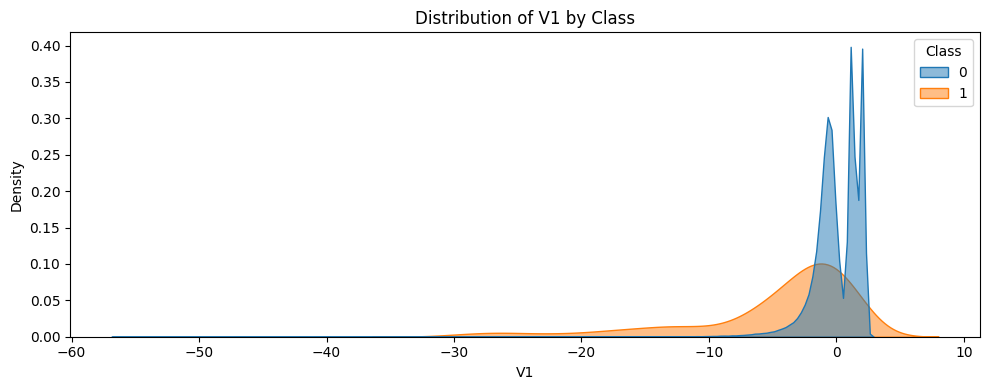

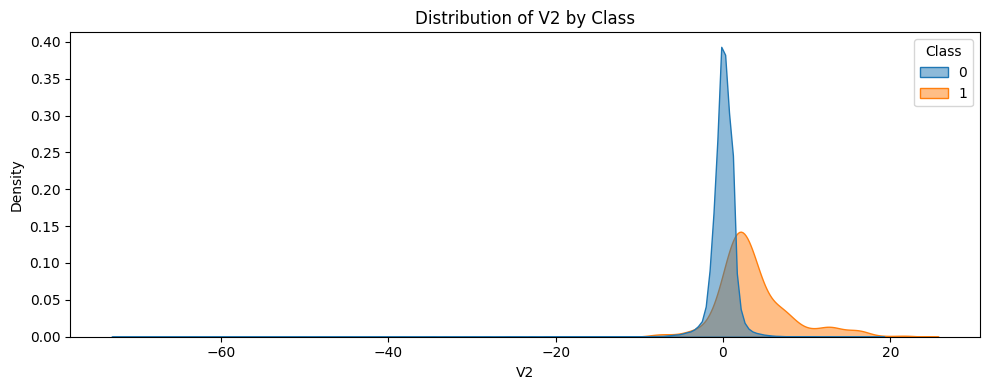

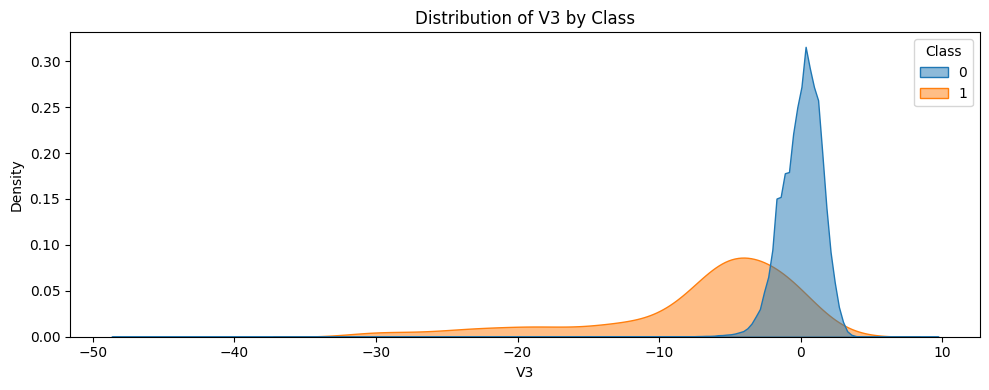

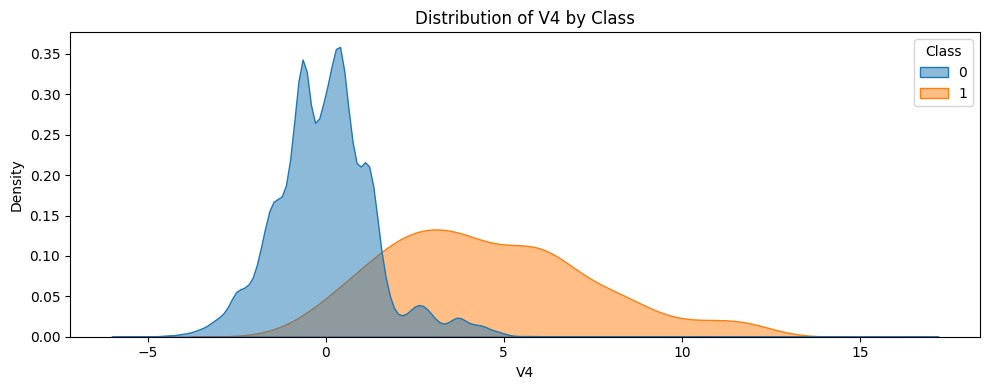

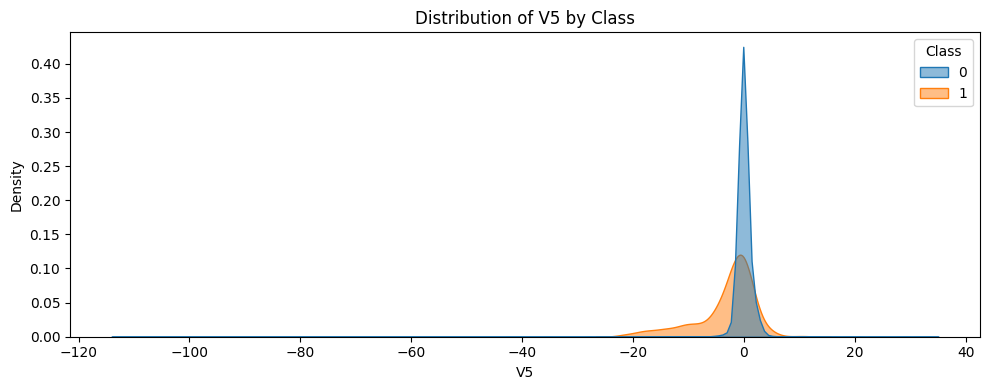

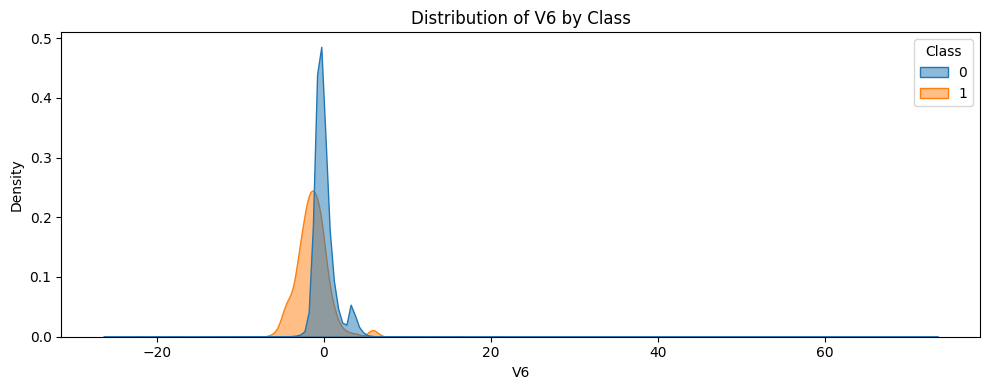

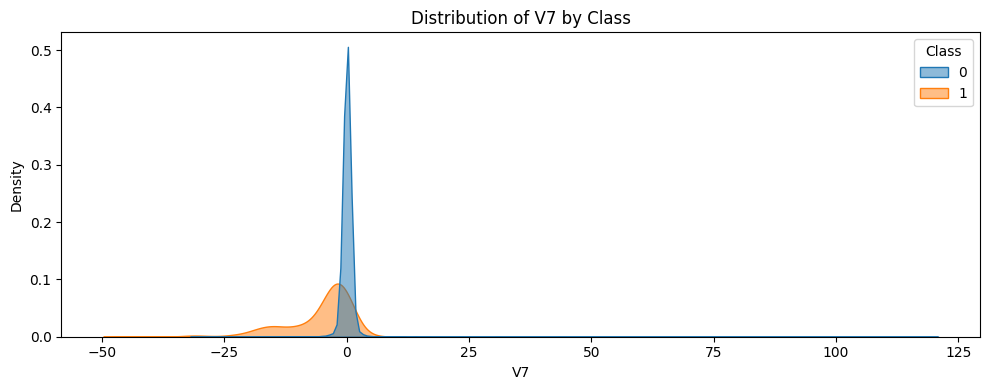

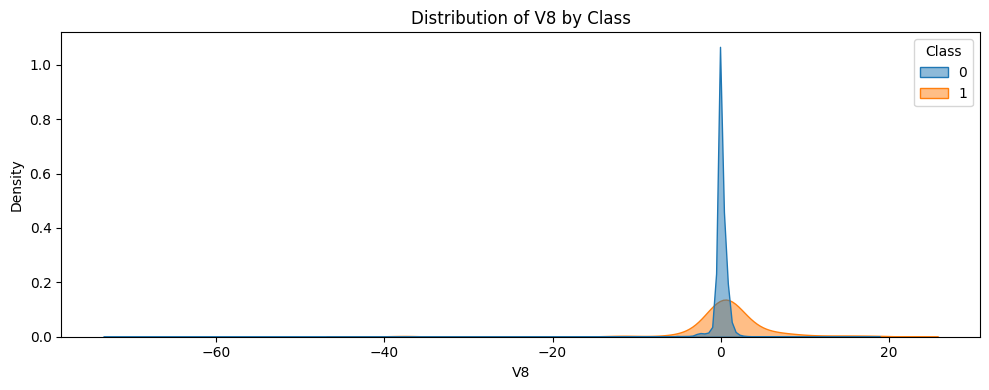

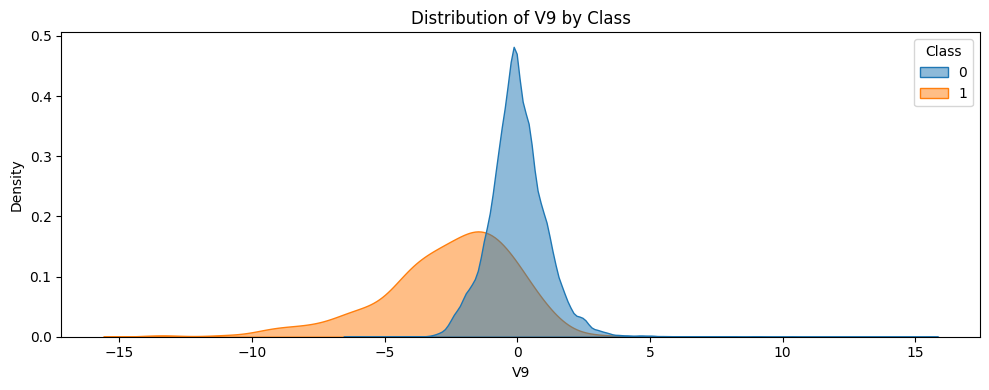

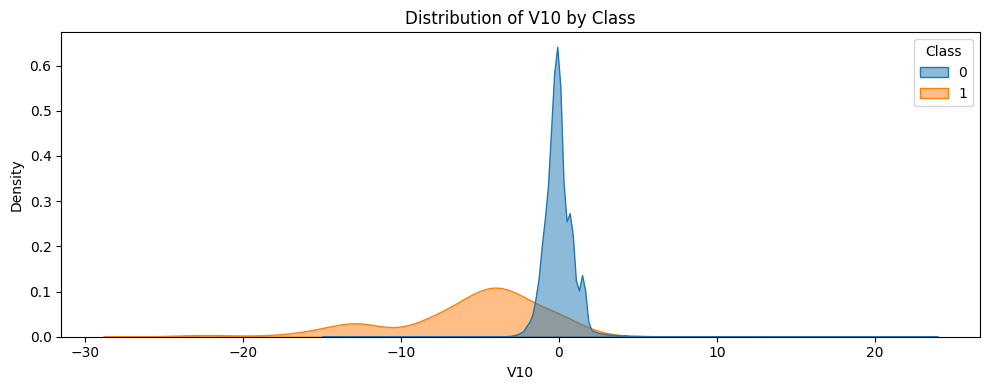

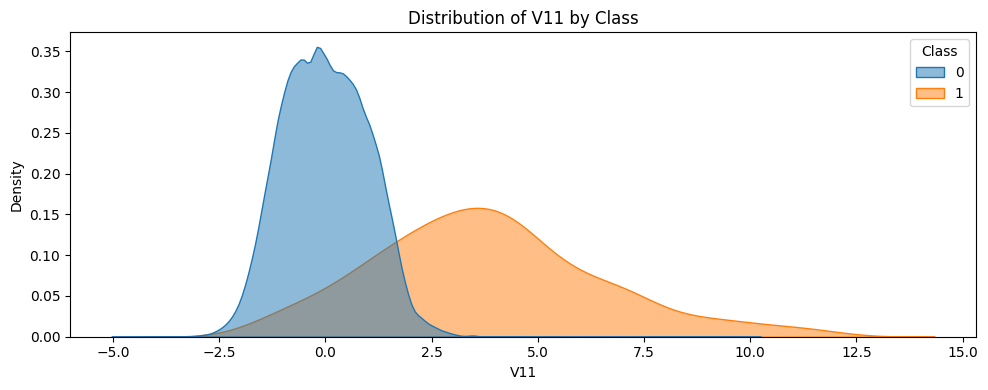

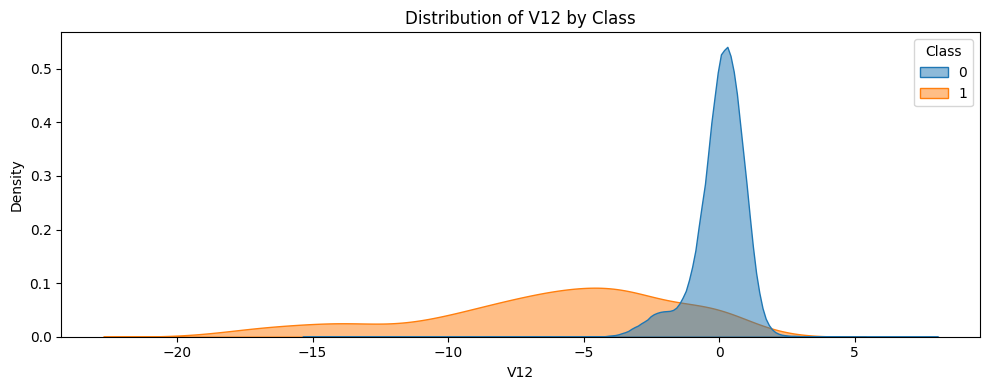

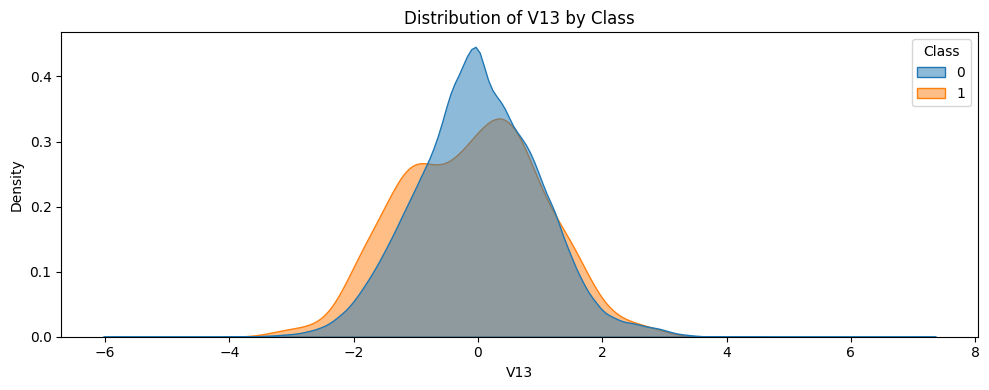

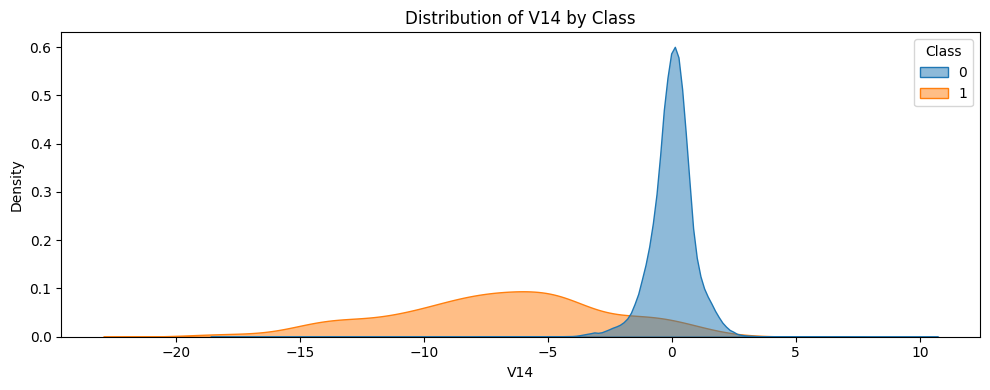

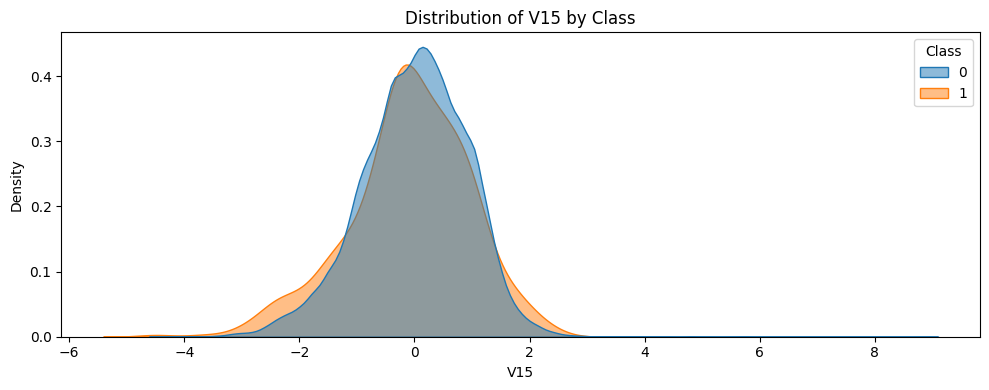

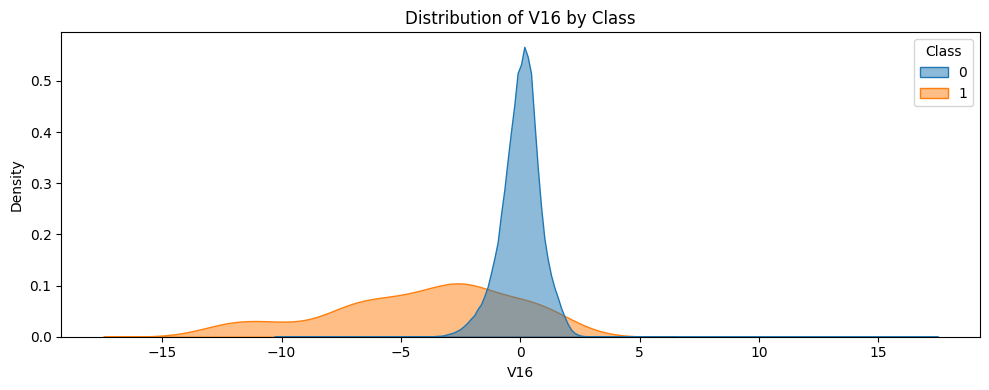

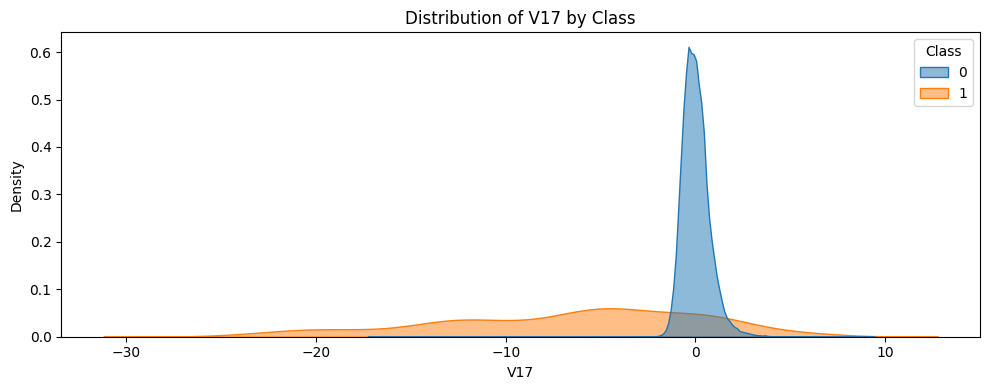

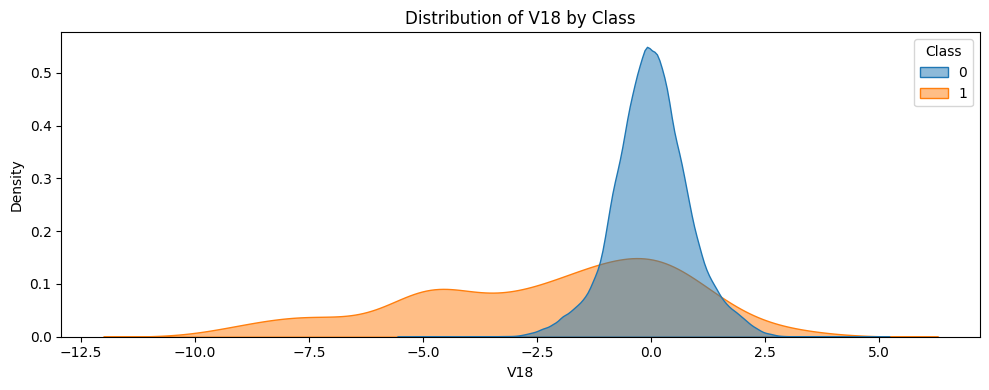

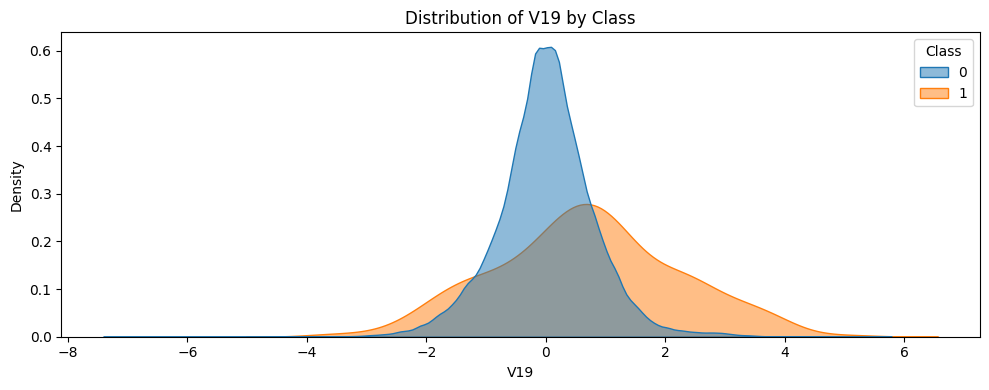

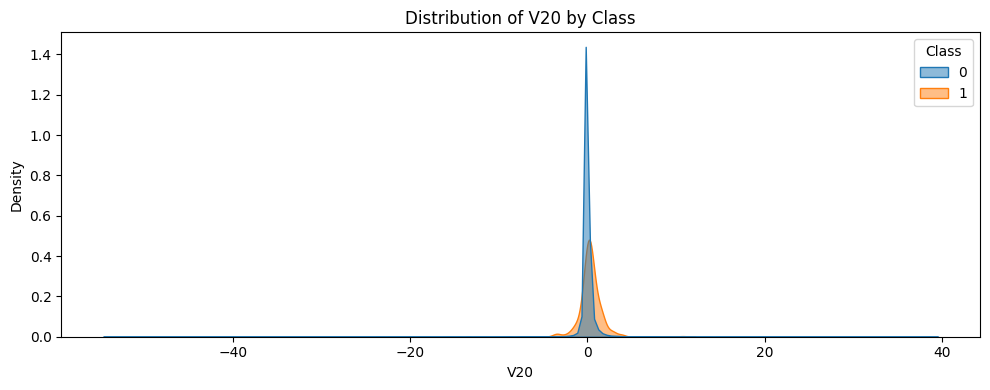

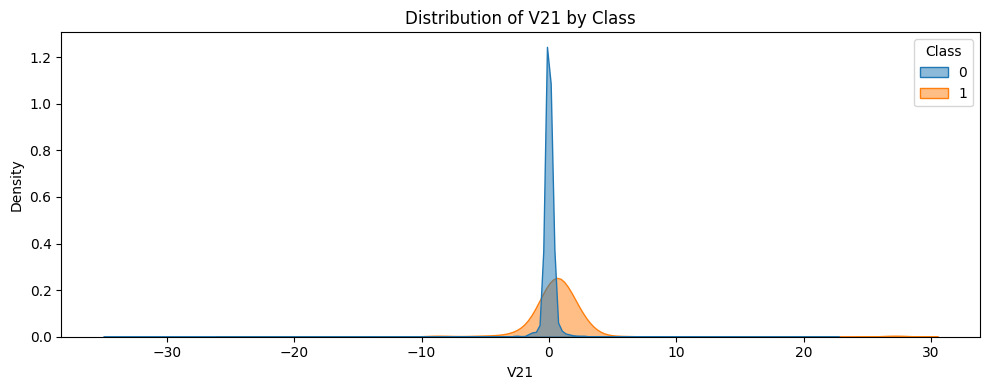

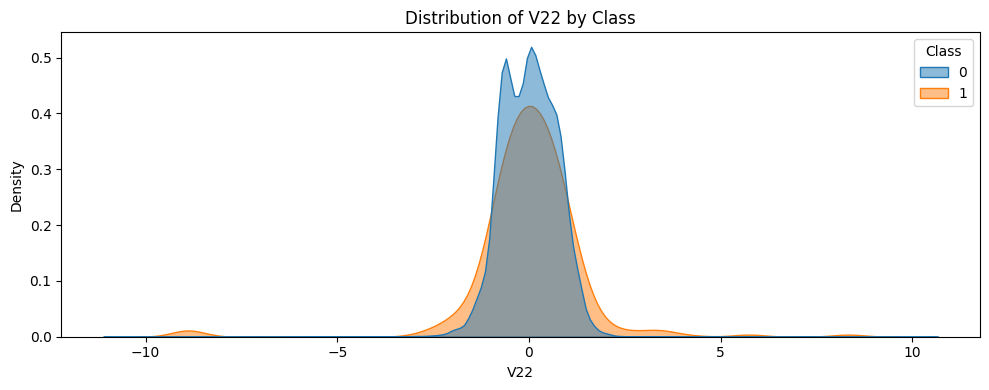

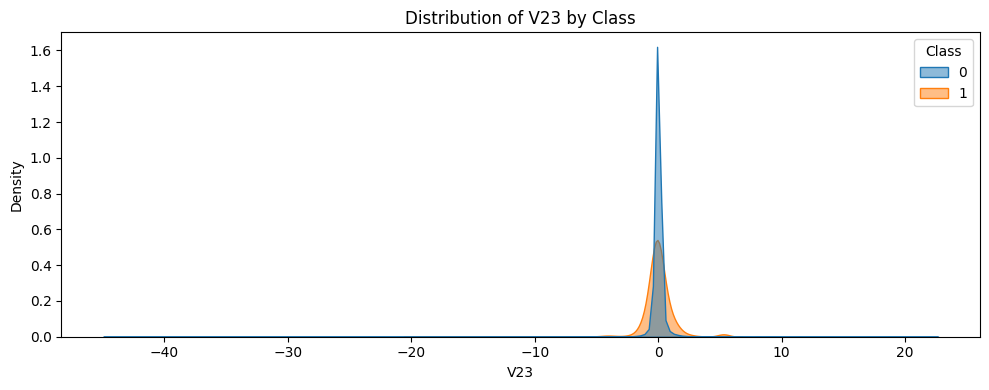

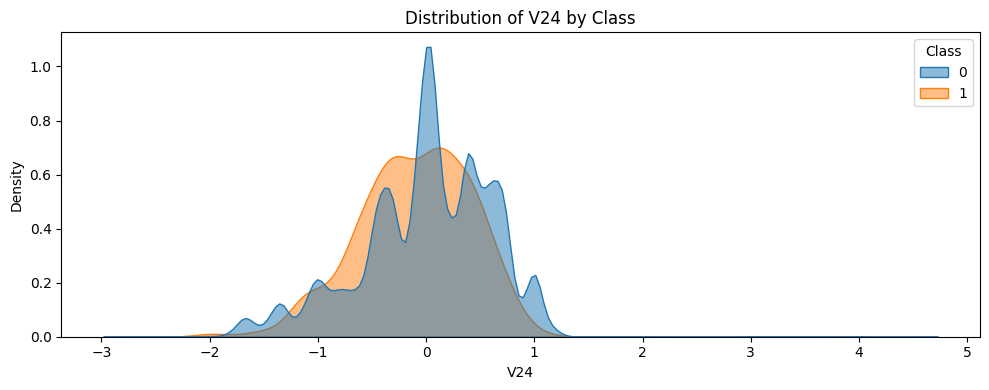

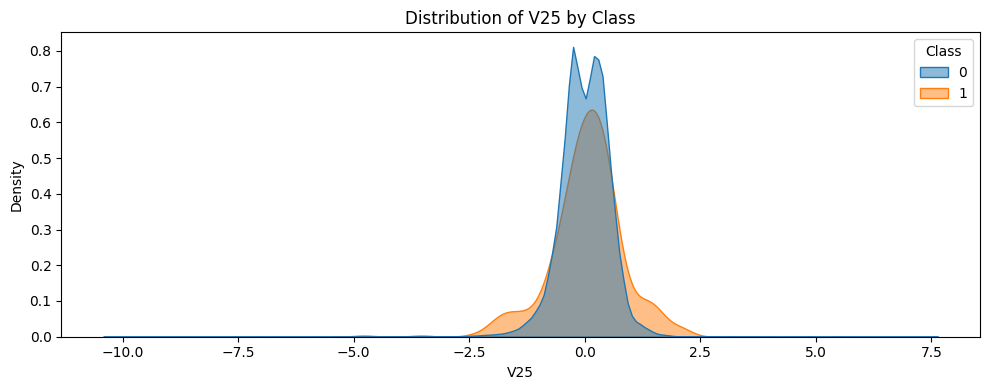

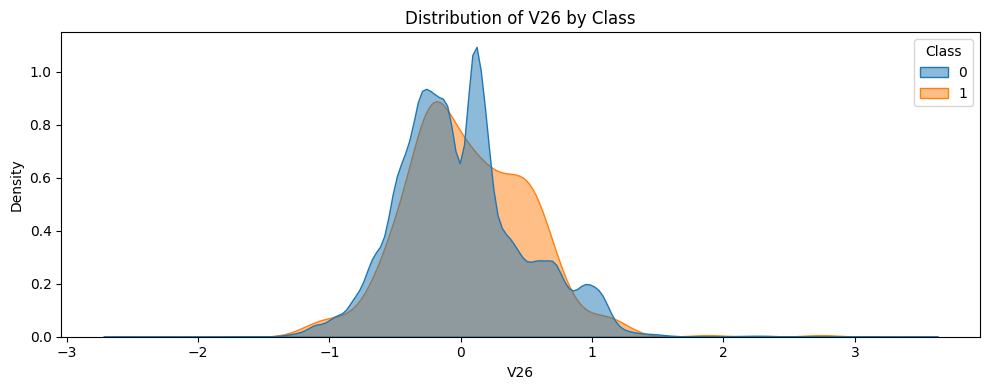

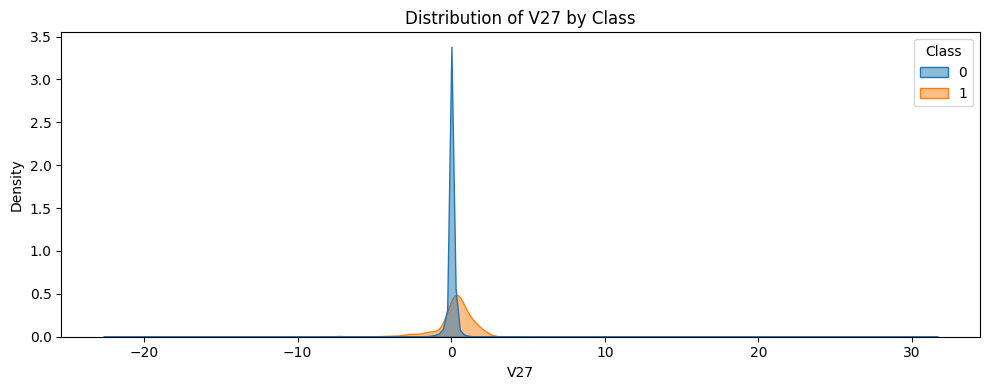

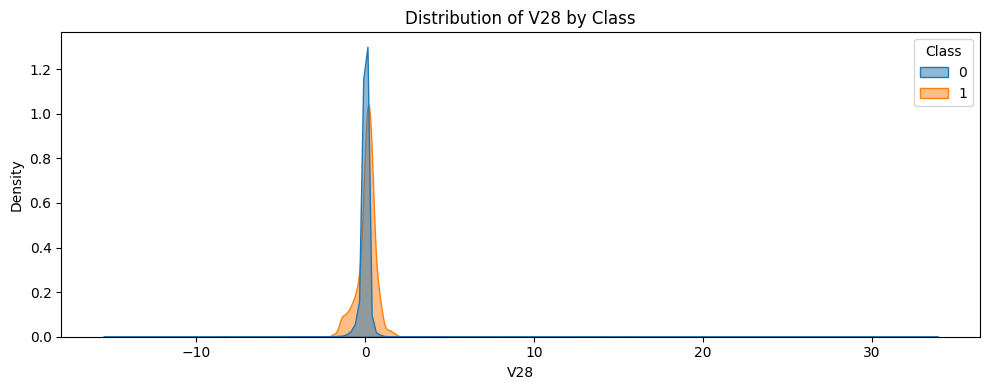

In [ ]:
# KDE plot for all V1–V28 to check class-wise distribution
features = [f'V{i}' for i in range(1, 29)]

for feature in features:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(data=df, x=feature, hue='Class', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()


# 2.7 Feature Correlation Heatmap

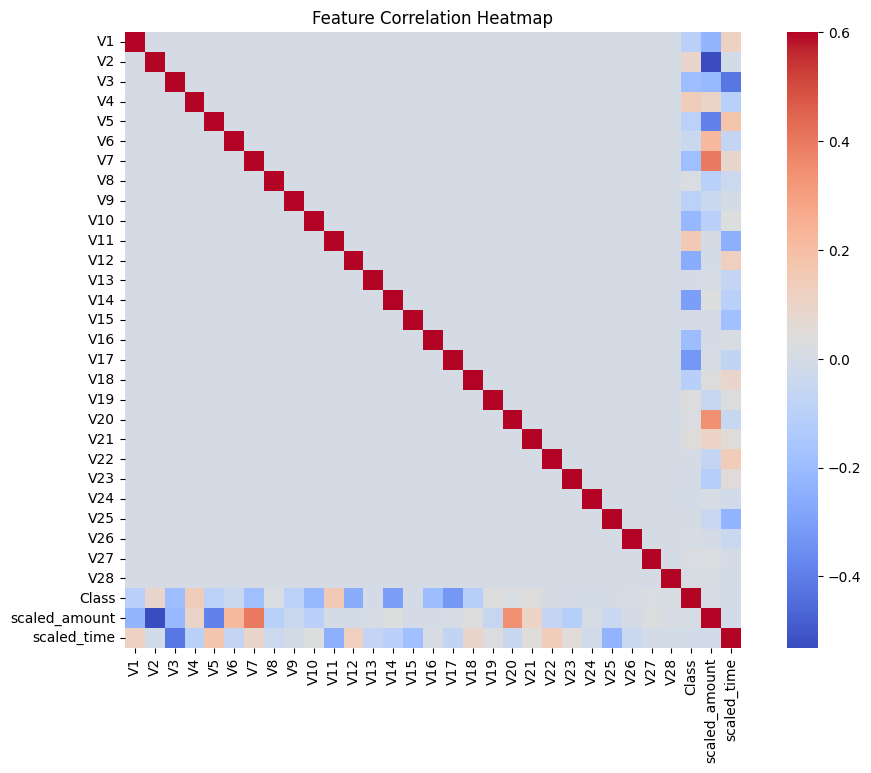

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", vmax=0.6, square=True)
plt.title("Feature Correlation Heatmap")
plt.show()

## 2.8 Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd # Import pandas as it's used here implicitly

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (227845, 30)
Test shape: (56962, 30)


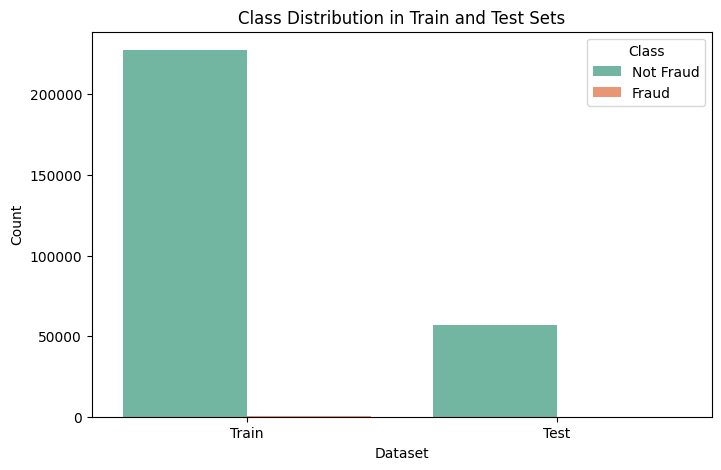

In [ ]:
# Create DataFrame to compare
train_df = pd.DataFrame({'Class': y_train})
train_df['Set'] = 'Train'

test_df = pd.DataFrame({'Class': y_test})
test_df['Set'] = 'Test'

combined = pd.concat([train_df, test_df])

# Plot
plt.figure(figsize=(8, 5))
sns.countplot(data=combined, x='Set', hue='Class', palette='Set2')
plt.title('Class Distribution in Train and Test Sets')
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.legend(title='Class', labels=['Not Fraud', 'Fraud'])
plt.show()

## 2.9 Summary of Preprocessing Steps

| Step                    | Method                      |
|-------------------------|-----------------------------|
| Class Imbalance         | Bar plot + value_counts     |
| Missing Values          | `isnull().sum()`            |
| Outlier Detection       | Boxplot of `Amount`         |
| Feature Scaling         | `StandardScaler` on Amount/Time |
| Train-Test Split        | Stratified 80/20 split      |


### EDA Summary

- The dataset contains no missing values.
- The class distribution is highly imbalanced: only a small fraction of the transactions are fraud.
- Outliers were observed in the `Amount` feature, which was normalized using StandardScaler.
- `Time` was also scaled and both `Amount` and `Time` were replaced with their scaled versions.
- The dataset has been split into training and test sets using stratified sampling to preserve the class distribution.

These preprocessing steps ensure the dataset is ready for the next phase: feat